# Is dealer hedging calming this stock down, or speeding it up?

**How The Markets Work** ([youtube.com/@HowTheMarketsWork](https://www.youtube.com/@HowTheMarketsWork)) · Episode 001: *Roaring Kitty vs Wall Street: The Real GameStop Story*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HowTheMarketsWork/notebooks/blob/main/001-roaring-kitty-vs-wall-street/gex_calculator.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/HowTheMarketsWork/notebooks/main?labpath=001-roaring-kitty-vs-wall-street%2Fgex_calculator.ipynb)

**How to use it:** open it in Colab, type a ticker in the box in Step 1, then click *Runtime > Run all*. In about 30 seconds you get:

1. **The regime** today: are market makers' hedges likely to *damp* this stock's moves or *amplify* them?
2. **The flip level**: the price where that regime would change.
3. **The walls**: the strikes where hedging pressure is biggest.
4. **A plain-English read** of what that means, and what it does *not* mean.

Every step below says what it is doing and why, so you finish knowing how the number is built, not just what it is.

> **Can I check GameStop in January 2021 with this?** Not with free data. This notebook reads *today's* options chain; no free source keeps the per-strike open interest of past days, so a 2021 replay needs paid historical data. What you *can* check about January 2021: the [SEC staff report](https://www.sec.gov/files/staff-report-equity-options-market-struction-conditions-early-2021.pdf), page 29 ("staff did not find evidence of a gamma squeeze in GME"), and the last exercise in *Try this next*, which shows how one assumption about market makers turns this calculation into the gamma-squeeze story people believed.

## Step 1: pick a stock

Type any US ticker with listed options (for example `GME`, `TSLA`, `AAPL`, `SPY`).

- **Expiries to include:** gamma is biggest in the options closest to expiring, so the nearest few expiries matter most. 4 is a good start.
- If live data can't be loaded (Yahoo Finance is free but sometimes busy), the notebook falls back to a built-in **sample** chain and says so.
- **When is the data from?** Step 3 prints it: the price is about 15 minutes delayed (or the last close when the market is shut), option quotes are each strike's last trade, and open interest is as of the previous trading day's close. Run it during market hours for the freshest read; open interest still changes only once a day.

In [1]:
TICKER = "GME"            #@param {type:"string"}
EXPIRIES_TO_INCLUDE = 4   #@param {type:"slider", min:1, max:12, step:1}
RISK_FREE_RATE = 0.04     #@param {type:"number"}

## Step 2: load the tools

`numpy`, `scipy` and `matplotlib` do the math and the charts. `yfinance` reads the options chain from Yahoo Finance (free, no key). In Colab everything installs itself.

In [2]:
import sys, subprocess, datetime as dt
try:
    import yfinance as yf
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance"], check=False)
    import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({"figure.facecolor": "#0B0E14", "axes.facecolor": "#161B22", "text.color": "#F0F6FC",
                     "axes.labelcolor": "#F0F6FC", "xtick.color": "#8B949E", "ytick.color": "#8B949E",
                     "grid.color": "#30363D", "grid.linestyle": "--", "grid.alpha": 0.5})
print("Ready.")

Ready.


## Step 3: get the options chain

For each of the nearest expiries we read every call and put: its **strike**, its **open interest** (how many contracts are still open) and its **implied volatility** (the market's priced-in expected movement). We drop contracts nobody holds and quotes that are obviously broken.

In [3]:
def load_live_chain(ticker, n_expiries):
    tk = yf.Ticker(ticker)
    spot = float(tk.fast_info["last_price"])
    hist = tk.history(period="1mo")
    adv = float((hist["Close"] * hist["Volume"]).mean()) if len(hist) else None
    bars = tk.history(period="5d", interval="1m")
    price_time = bars.index[-1].tz_convert("America/New_York") if len(bars) else None
    rows = []
    for exp in list(tk.options)[:n_expiries]:
        ch = tk.option_chain(exp)
        for kind, df in (("call", ch.calls), ("put", ch.puts)):
            d = df[["strike", "openInterest", "impliedVolatility", "lastTradeDate"]].copy()
            d["type"], d["expiry"] = kind, exp
            rows.append(d)
    chain = pd.concat(rows, ignore_index=True).rename(columns={"openInterest": "oi", "impliedVolatility": "iv"})
    quote_time = pd.to_datetime(chain["lastTradeDate"], utc=True).max().tz_convert("America/New_York")
    chain = chain.drop(columns="lastTradeDate").dropna()
    chain = chain[(chain.oi > 0) & (chain.iv > 0.01) & (chain.iv < 5)]
    times = {"price": price_time, "quotes": quote_time}
    return spot, chain, adv, times

def load_sample_chain():
    spot, strikes = 100.0, np.arange(80, 122, 2)
    call_oi = [500, 800, 1200, 2500, 4200, 7800, 15000, 28000, 19000, 12000, 8000, 5000, 3000, 1500, 800, 400, 200, 100, 50, 20, 10]
    put_oi = [20, 50, 120, 400, 1100, 2800, 6500, 14000, 22000, 16000, 9000, 4500, 2100, 900, 400, 150, 80, 30, 10, 5, 2]
    exp = (dt.date.today() + dt.timedelta(days=14)).isoformat()
    chain = pd.concat([pd.DataFrame({"strike": strikes, "oi": call_oi, "iv": 0.35, "type": "call", "expiry": exp}),
                       pd.DataFrame({"strike": strikes, "oi": put_oi, "iv": 0.35, "type": "put", "expiry": exp})])
    return spot, chain, None, None

try:
    SPOT, CHAIN, ADV, TIMES = load_live_chain(TICKER.strip().upper(), EXPIRIES_TO_INCLUDE)
    if CHAIN.empty:
        raise ValueError("no usable contracts")
    SOURCE = f"LIVE {TICKER.strip().upper()} options chain from Yahoo Finance (delayed; open interest updates once a day)"
except Exception as e:
    SPOT, CHAIN, ADV, TIMES = load_sample_chain()
    SOURCE = f"SAMPLE chain (no live options data for {TICKER.strip().upper()!r}: check the ticker has listed options, or try again in a minute)"

print(SOURCE)
def et(ts):
    return ts.strftime("%a %b %d %Y, %I:%M %p ET") if ts is not None else "unknown"
if TIMES:
    DATA_DATE = TIMES["price"].strftime("%b %d, %Y") if TIMES["price"] is not None else dt.date.today().strftime("%b %d, %Y")
    print(f"Price as of:         {et(TIMES['price'])} (about 15 minutes delayed during market hours)")
    print(f"Option quotes up to: {et(TIMES['quotes'])} (each strike's last trade; quiet strikes can be older)")
    print("Open interest:       as of the previous trading day's close (it is counted once a day, overnight)")
else:
    DATA_DATE = "sample data"
    print("Data time: none (sample chain, not market data)")
print(f"Price: ${SPOT:,.2f} | expiries: {CHAIN.expiry.nunique()} ({', '.join(sorted(CHAIN.expiry.unique()))})")
print(f"Contracts used: {len(CHAIN):,} | open interest: {int(CHAIN.oi.sum()):,} contracts")

LIVE GME options chain from Yahoo Finance (delayed; open interest updates once a day)
Price as of:         Mon Oct 05 2026, 03:59 PM ET (about 15 minutes delayed during market hours)
Option quotes up to: Mon Oct 05 2026, 04:00 PM ET (each strike's last trade; quiet strikes can be older)
Open interest:       as of the previous trading day's close (it is counted once a day, overnight)
Price: $25.24 | expiries: 4 (2026-10-09, 2026-10-16, 2026-10-23, 2026-10-30)
Contracts used: 281 | open interest: 589,109 contracts


## Step 4: what market makers have to do

When you buy an option, a **market maker** usually takes the other side. They don't want to bet on direction, so they **hedge** with shares: this is called staying *delta-neutral*.

- **Delta** = how much an option's price moves for a $1 move in the stock.
- **Gamma** = how fast delta changes. It tells you how many *more* shares the market maker must buy or sell as the stock moves.

If market makers are **long gamma**, their hedging is *sell into rallies, buy into dips*: it **damps** moves.
If they are **short gamma**, it's *buy into rallies, sell into dips*: it **amplifies** moves. That second case is the "gamma squeeze" everyone talked about with GameStop.

For each contract we compute Black-Scholes gamma, using that contract's own implied volatility and its own time to expiry.

In [4]:
def bs_gamma(S, K, iv, T, r=RISK_FREE_RATE):
    T = np.maximum(T, 1 / 365)
    d1 = (np.log(S / K) + (r + 0.5 * iv ** 2) * T) / (iv * np.sqrt(T))
    return norm.pdf(d1) / (S * iv * np.sqrt(T))

today = pd.Timestamp(dt.date.today())
CHAIN["T"] = ((pd.to_datetime(CHAIN.expiry) - today).dt.days.clip(lower=1)) / 365.0
print(f"Gamma computed for {len(CHAIN):,} contracts.")

Gamma computed for 281 contracts.


## Step 5: the one assumption you must know about

Nobody outside the market makers knows their real positions. So every GEX calculator, including this one, has to **assume** a sign:

> Market makers are **long the calls** customers sell them and **short the puts** customers buy from them.

So **call gamma counts as positive** (damping) and **put gamma counts as negative** (amplifying). This is the common convention, not a fact. In GameStop's case the SEC staff report found market makers were *buying* calls, which is exactly why the gamma-squeeze story did not hold up.

**Dollar GEX** for each strike = gamma x open interest x 100 shares x price x (1% of price): the dollars of stock market makers would need to trade for a 1% move.

In [5]:
def gex_by_strike(S, chain):
    sign = np.where(chain["type"] == "call", 1.0, -1.0)
    dollars = sign * bs_gamma(S, chain.strike.values, chain.iv.values, chain["T"].values) * chain.oi.values * 100 * S * S * 0.01
    return pd.Series(dollars, index=chain.strike.values).groupby(level=0).sum()

BY_STRIKE = gex_by_strike(SPOT, CHAIN)
TOTAL = BY_STRIKE.sum()

# Where does the regime flip? Recompute total GEX as if the price were somewhere else.
grid = np.linspace(SPOT * 0.7, SPOT * 1.3, 241)
profile = np.array([gex_by_strike(s, CHAIN).sum() for s in grid])
crossings = [grid[i] for i in range(1, len(grid)) if np.sign(profile[i]) != np.sign(profile[i - 1])]
FLIP = min(crossings, key=lambda x: abs(x - SPOT)) if crossings else None
CALL_WALL = BY_STRIKE.idxmax() if (BY_STRIKE > 0).any() else None
PUT_WALL = BY_STRIKE.idxmin() if (BY_STRIKE < 0).any() else None

def money(x):
    return f"{'+' if x >= 0 else '-'}${abs(x) / 1e6:,.2f}M"
print(f"Total net GEX: {money(TOTAL)} per 1% move")
print(f"Flip level: {'$' + format(FLIP, ',.2f') if FLIP else 'none within +/-30% of price'}")
print(f"Biggest positive strike (call wall): {'$' + format(CALL_WALL, ',.2f') if CALL_WALL is not None else '-'}")
print(f"Biggest negative strike (put wall): {'$' + format(PUT_WALL, ',.2f') if PUT_WALL is not None else '-'}")

Total net GEX: +$21.44M per 1% move
Flip level: none within +/-30% of price
Biggest positive strike (call wall): $25.00
Biggest negative strike (put wall): $21.50


## Step 6: see it

**Top chart:** net GEX at each strike. Green bars damp moves near that price, red bars amplify them. The white line is today's price.
**Bottom chart:** total GEX if the stock were at a different price. Where the line crosses zero is the **flip level**.

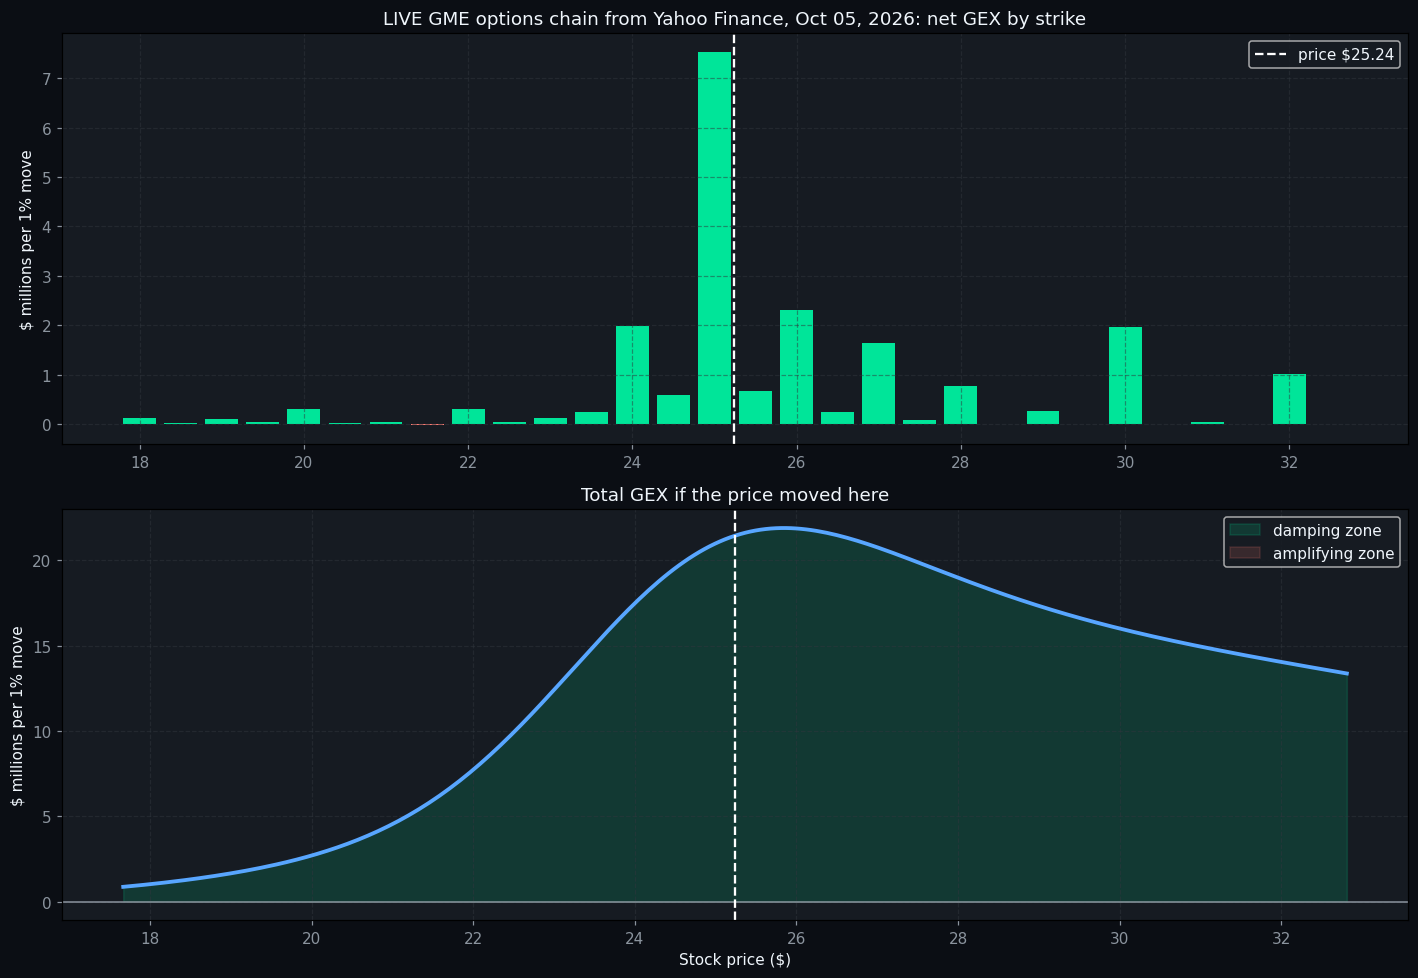

In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 9), dpi=110)
lo, hi = SPOT * 0.7, SPOT * 1.3
s = BY_STRIKE[(BY_STRIKE.index >= lo) & (BY_STRIKE.index <= hi)] / 1e6
width = max((hi - lo) / 120, (s.index[1] - s.index[0]) * 0.8) if len(s) > 1 else 1
a1.bar(s.index, s.values, width=width, color=np.where(s.values >= 0, "#00E599", "#FF7B72"))
a1.axvline(SPOT, color="white", ls="--", lw=1.5, label=f"price ${SPOT:,.2f}")
if FLIP: a1.axvline(FLIP, color="#58A6FF", ls=":", lw=1.5, label=f"flip ${FLIP:,.2f}")
a1.set_title(f"{SOURCE.split(' (')[0]}, {DATA_DATE}: net GEX by strike", fontsize=12); a1.set_ylabel("$ millions per 1% move"); a1.grid(True); a1.legend()
a2.plot(grid, profile / 1e6, color="#58A6FF", lw=2.5); a2.axhline(0, color="#8B949E", lw=1)
a2.axvline(SPOT, color="white", ls="--", lw=1.5)
a2.fill_between(grid, profile / 1e6, 0, where=profile >= 0, color="#00E599", alpha=0.15, label="damping zone")
a2.fill_between(grid, profile / 1e6, 0, where=profile < 0, color="#FF7B72", alpha=0.15, label="amplifying zone")
a2.set_title("Total GEX if the price moved here", fontsize=12); a2.set_xlabel("Stock price ($)"); a2.set_ylabel("$ millions per 1% move")
a2.grid(True); a2.legend()
plt.tight_layout(); plt.show()

## Step 7: what it means, in plain English

In [7]:
lines = []
if TOTAL >= 0:
    lines.append(f"At ${SPOT:,.2f}, total net GEX is {money(TOTAL)} per 1% move: market makers are most likely LONG gamma. "
                 "Their hedging tends to sell rallies and buy dips, which DAMPS moves.")
else:
    lines.append(f"At ${SPOT:,.2f}, total net GEX is {money(TOTAL)} per 1% move: market makers are most likely SHORT gamma. "
                 "Their hedging tends to buy rallies and sell dips, which can AMPLIFY moves.")
if FLIP:
    side = "below" if FLIP < SPOT else "above"
    lines.append(f"The flip level is about ${FLIP:,.2f}, {abs(FLIP / SPOT - 1):.1%} {side} today's price. "
                 "Cross it and the hedging behaviour reverses.")
else:
    lines.append("No flip level within 30% of today's price: the regime is unlikely to change on a normal move.")
if CALL_WALL is not None:
    lines.append(f"The biggest damping strike is ${CALL_WALL:,.2f}; the biggest amplifying strike is "
                 f"${PUT_WALL:,.2f}." if PUT_WALL is not None else f"The biggest damping strike is ${CALL_WALL:,.2f}.")
if ADV:
    share = abs(TOTAL) / ADV
    lines.append(f"Size check: the stock trades about ${ADV / 1e6:,.0f}M a day (1-month average). {money(TOTAL)} per 1% move is "
                 f"{share:.1%} of that. The bigger that share, the more market makers' hedging can push the price around; "
                 "it is a sense of scale, not a forecast.")
else:
    lines.append("Size check: not available for the sample chain. With live data this compares the hedging to normal daily trading.")
print("\n\n".join(lines))
print("\nWhat this does NOT tell you: direction, timing, or whether to buy or sell. It rests on an assumption about "
      "market makers' positions (Step 5), uses delayed data, and ignores everything else that moves a stock: news, "
      "earnings, short covering, other traders. Educational only, not advice.")

At $25.24, total net GEX is +$21.44M per 1% move: market makers are most likely LONG gamma. Their hedging tends to sell rallies and buy dips, which DAMPS moves.

No flip level within 30% of today's price: the regime is unlikely to change on a normal move.

The biggest damping strike is $25.00; the biggest amplifying strike is $21.50.

Size check: the stock trades about $246M a day (1-month average). +$21.44M per 1% move is 8.7% of that. The bigger that share, the more market makers' hedging can push the price around; it is a sense of scale, not a forecast.

What this does NOT tell you: direction, timing, or whether to buy or sell. It rests on an assumption about market makers' positions (Step 5), uses delayed data, and ignores everything else that moves a stock: news, earnings, short covering, other traders. Educational only, not advice.


## Try this next

1. **Change the ticker** and run again. Compare a calm large company (`AAPL`) with a meme stock.
2. **Change Expiries to include** from 1 to 12. Watch how much of the picture comes from the next few weeks.
3. **Run it again tomorrow.** Open interest updates once a day, so the walls and the flip level move.
4. **Back to GameStop:** the "gamma squeeze" story assumed market makers had *sold* all those calls to retail traders (short gamma, amplifying). The SEC staff report (page 29) found market makers were *buying* calls, which matches this notebook's convention: long gamma, damping. To see the story people believed, change `1.0, -1.0` to `-1.0, -1.0` in Step 5's code and run it again.

Educational material only. Nothing here is financial, investment, legal or tax advice.